In [1]:
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# Visualizando propriedades do grafo gerado

In [2]:
# G = pickle.load(open("../data/processed/strict_iqr3_ai_news_event_graph.pkl", "rb"))
G = pickle.load(open("../data/processed/directed_mad3.5_ai_news_event_graph.pkl", "rb"))

In [3]:
# graph infos
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 14605
Number of edges: 180967


Text(0.5, 1.0, 'Distribuição de graus')

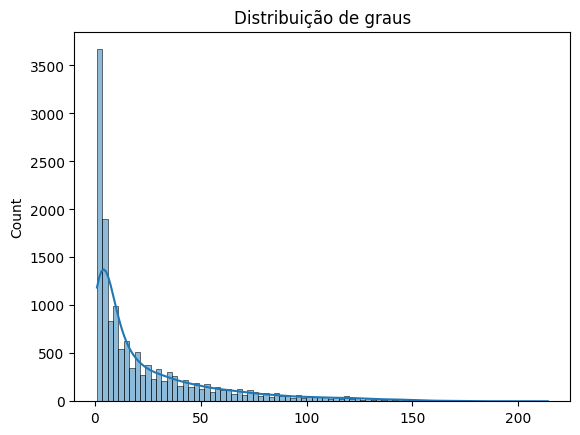

In [4]:
degrees = dict(G.degree())
sns.histplot(list(degrees.values()), kde=True)
plt.title("Distribuição de graus")


In [5]:
all_edges = list(G.edges(data=True))

In [6]:
all_weights = np.array([edge[2]['weight'] for edge in all_edges])

In [7]:
# os campos de simlaridade podem ou nao existir
what_sims = np.array([edge[2]['what_sim'] for edge in all_edges if 'what_sim' in edge[2]])
where_sims = np.array([edge[2]['where_sim'] for edge in all_edges if 'where_sim' in edge[2]])
when_sims = np.array([edge[2]['when_sim'] for edge in all_edges if 'when_sim' in edge[2]])

Text(0.5, 1.0, 'Distribution of When Similarities')

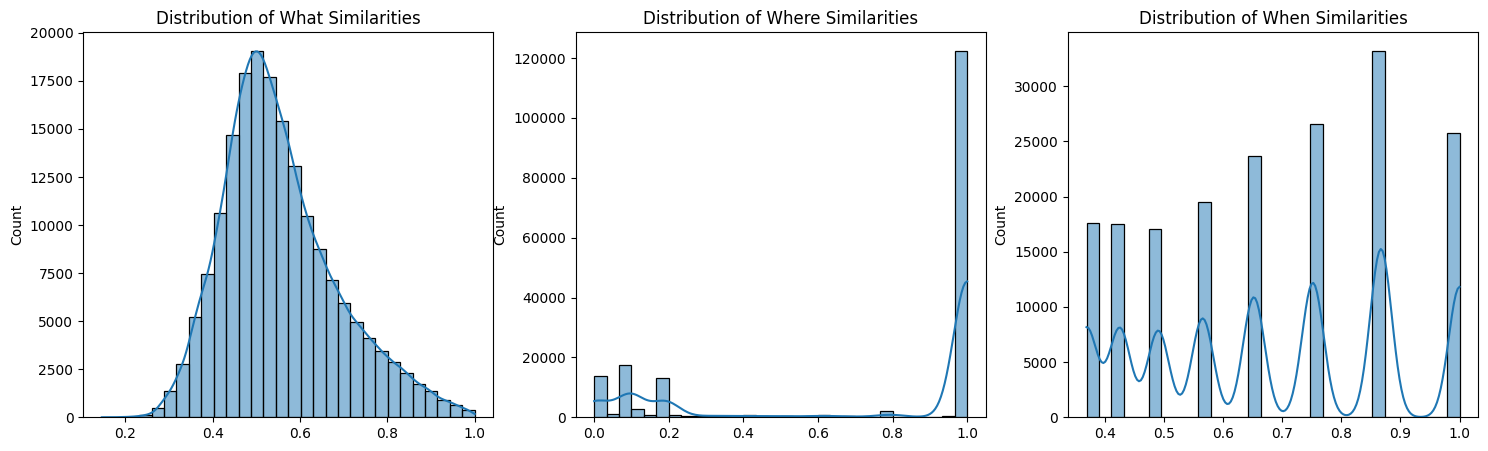

In [8]:
# visualizando pesos/similaridades por tipo (what, where, when)
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.histplot(what_sims, bins=30, kde=True)
plt.title('Distribution of What Similarities')
plt.subplot(1, 3, 2)
sns.histplot(where_sims, bins=30, kde=True)
plt.title('Distribution of Where Similarities')
plt.subplot(1, 3, 3)
sns.histplot(when_sims, bins=30, kde=True)
plt.title('Distribution of When Similarities')

In [9]:
# estatisticas descritivas dos pesos
print(f"Mean weight: {all_weights.mean():.4f}")
print(f"Median weight: {np.median(all_weights):.4f}")
print(f"Standard deviation: {all_weights.std():.4f}")
print(f"Min weight: {all_weights.min()}")
print(f"Max weight: {all_weights.max():.4f}")
q1 = np.percentile(all_weights, 25)
q3 = np.percentile(all_weights, 75)
p90 = np.percentile(all_weights, 90)
print(f"Q1 (25th percentile): {q1:.4f}")
print(f"Q3 (75th percentile): {q3:.4f}")
print(f"P90 (90th percentile): {p90:.4f}")


Mean weight: 0.5545
Median weight: 0.5331
Standard deviation: 0.1312
Min weight: 0.1466137319803238
Max weight: 0.9997
Q1 (25th percentile): 0.4637
Q3 (75th percentile): 0.6280
P90 (90th percentile): 0.7420


# Definindo limiares para criação de arestas

In [10]:
# TODO: boa margem para customizar os intervalos
# definindo um critério para filtrar arestas (exemplo: peso acima do percentil 90)
easy = (p90, np.inf)  # arestas "fáceis" com peso acima do percentil 90
medium = (q3, p90)     # arestas "médias" com peso entre o percentil 75 e 90
hard = (0, q1)         # arestas "difíceis" com peso entre 0 e o percentil 25

# Visualizando limiares

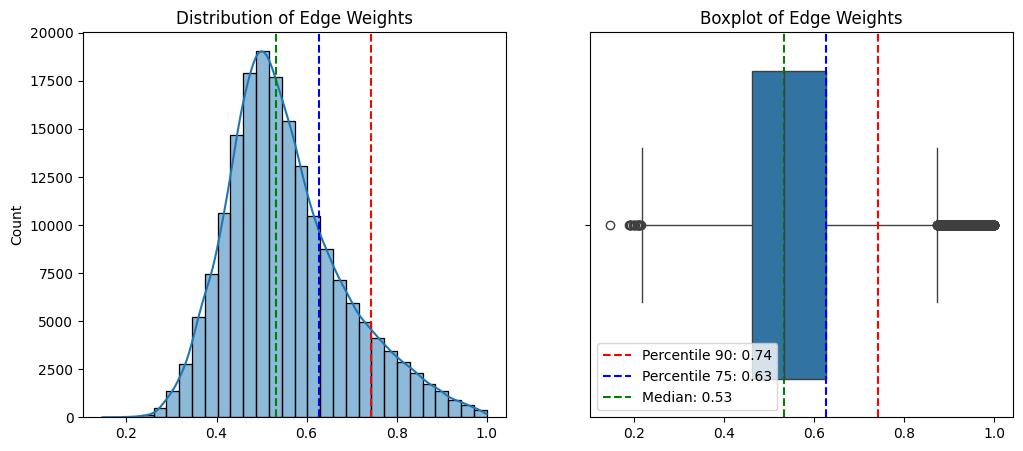

In [11]:
# histograma e boxplot, com limiar escolhido
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(all_weights, bins=30, kde=True)
plt.axvline(p90, color='red', linestyle='--', label=f'Percentile 90: {p90:.2f}')
plt.axvline(q3, color='blue', linestyle='--', label=f'Percentile 75: {q3:.2f}')
plt.axvline(np.median(all_weights), color='green', linestyle='--', label=f'Median: {np.median(all_weights):.2f}')
plt.title('Distribution of Edge Weights')
plt.subplot(1, 2, 2)
sns.boxplot(x=all_weights)
plt.axvline(p90, color='red', linestyle='--', label=f'Percentile 90: {p90:.2f}')
plt.axvline(q3, color='blue', linestyle='--', label=f'Percentile 75: {q3:.2f}')
plt.axvline(np.median(all_weights), color='green', linestyle='--', label=f'Median: {np.median(all_weights):.2f}')
plt.title('Boxplot of Edge Weights')
plt.legend()
plt.show()

# Filtrando arestas 

In [ ]:
from glm_based_event_analysis.utils.sampling import *

In [13]:
easy_edges = filter_edges_by_weight_range(all_edges, easy[0], easy[1])
medium_edges = filter_edges_by_weight_range(all_edges, medium[0], medium[1])
hard_edges = filter_edges_by_weight_range(all_edges, hard[0], hard[1])

In [14]:
# quantidades por grupo
print(f"Number of easy edges: {len(easy_edges)}")
print(f"Number of medium edges: {len(medium_edges)}")
print(f"Number of hard edges: {len(hard_edges)}")

Number of easy edges: 18098
Number of medium edges: 27144
Number of hard edges: 45242


In [15]:
easy_weights = [d['weight'] for u, v, d in easy_edges]
medium_weights = [d['weight'] for u, v, d in medium_edges]
hard_weights = [d['weight'] for u, v, d in hard_edges]

Text(0.5, 1.0, 'Distribution of Hard Edge Weights')

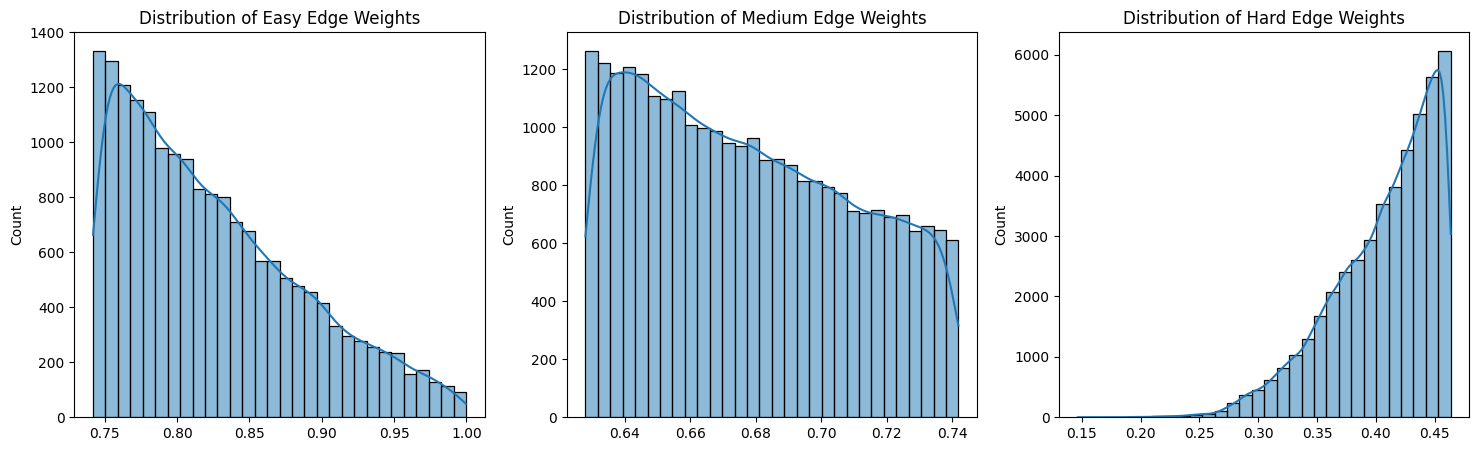

In [16]:
# visualizando pesos dos grupos
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.histplot(easy_weights, bins=30, kde=True)
plt.title('Distribution of Easy Edge Weights')  
plt.subplot(1, 3, 2)
sns.histplot(medium_weights, bins=30, kde=True)
plt.title('Distribution of Medium Edge Weights')
plt.subplot(1, 3, 3)
sns.histplot(hard_weights, bins=30, kde=True)
plt.title('Distribution of Hard Edge Weights')

# Amostrando exemplos de cada grupo

In [17]:
# arestas do grupo "fácil" 
easy_weights = np.array(easy_weights)
sampled_edge_ids = np.random.choice(np.arange(len(easy_weights)), size=5, replace=False, p=easy_weights / easy_weights.sum())

for idx in sampled_edge_ids:
    u, v, d = easy_edges[idx]
    print(f"Edge ({u}, {v}) - weight: {d['weight']:.4f}, what_sim: {d.get('what_sim', 'N/A'):.4f}, where_sim: {d.get('where_sim', 'N/A'):.4f}, when_sim: {d.get('when_sim', 'N/A'):.4f}")
    print("\t- Event 1:")
    print("\t\t- What:", G.nodes[u]['what'])
    print("\t\t- Where:", G.nodes[u]['where'])
    print("\t\t- When:", G.nodes[u]['when'])
    print("\t- Event 2:")
    print("\t\t- What:", G.nodes[v]['what'])
    print("\t\t- Where:", G.nodes[v]['where'])
    print("\t\t- When:", G.nodes[v]['when'])
    print()

Edge (536_anthropic_pentagon_lawsuit_2026-03-09, 10106_ai_pentagon_anthropic_2026-03-12) - weight: 0.7898, what_sim: 0.7898, where_sim: 1.0000, when_sim: 0.6514
	- Event 1:
		- What: Anthropic is suing the Pentagon over a 'supply chain risk' label.
		- Where: United States
		- When: 2026-03-09 07:00:00+00:00
	- Event 2:
		- What: Anthropic is suing the Pentagon over AI safety concerns.
		- Where: United States
		- When: 2026-03-12 07:00:00+00:00

Edge (3844_ai_thought_homogenizing_2026-03-11, 3892_ai_thought_expression_2026-03-13) - weight: 0.9017, what_sim: 0.9017, where_sim: 1.0000, when_sim: 0.7515
	- Event 1:
		- What: Artificial intelligence is leading to a homogenization of thought processes.
		- Where: United States
		- When: 2026-03-11 07:00:00+00:00
	- Event 2:
		- What: A study suggests that artificial intelligence may be leading to a homogenization of human thought and expression.
		- Where: United States
		- When: 2026-03-13 07:00:00+00:00

Edge (5807_openai_acquisition_sec

In [18]:
# arestas do grupo "medio" 
medium_weights = np.array(medium_weights)
sampled_edge_ids = np.random.choice(np.arange(len(medium_weights)), size=5, replace=False, p=medium_weights / medium_weights.sum())

for idx in sampled_edge_ids:
    u, v, d = medium_edges[idx]
    print(f"Edge ({u}, {v}) - weight: {d['weight']:.4f}, what_sim: {d.get('what_sim', 'N/A'):.4f}, where_sim: {d.get('where_sim', 'N/A'):.4f}, when_sim: {d.get('when_sim', 'N/A'):.4f}")
    print("\t- Event 1:")
    print("\t\t- What:", G.nodes[u]['what'])
    print("\t\t- Where:", G.nodes[u]['where'])
    print("\t\t- When:", G.nodes[u]['when'])
    print("\t- Event 2:")
    print("\t\t- What:", G.nodes[v]['what'])
    print("\t\t- Where:", G.nodes[v]['where'])
    print("\t\t- When:", G.nodes[v]['when'])
    print()

Edge (2477_ai_film_val_kilmer_2026-03-20, 2434_ai_film_kilmer_2026-03-20) - weight: 0.6752, what_sim: 0.6752, where_sim: 1.0000, when_sim: 1.0000
	- Event 1:
		- What: An AI-generated version of actor Val Kilmer will star in a new film.
		- Where: United States
		- When: 2026-03-20 07:00:00+00:00
	- Event 2:
		- What: Val Kilmer is being digitally resurrected using AI technology to appear in his final film.
		- Where: United States
		- When: 2026-03-20 07:00:00+00:00

Edge (6813_maps_driving_directions_2026-03-12, 6769_navigation_ai_maps_2026-03-12) - weight: 0.6342, what_sim: 0.6342, where_sim: 1.0000, when_sim: 1.0000
	- Event 1:
		- What: Google Maps introduces 3D maps to driving directions.
		- Where: United States
		- When: 2026-03-12 07:00:00+00:00
	- Event 2:
		- What: Google introduces 'Ask Maps' feature, enabling users to ask complex questions for navigation.
		- Where: United States
		- When: 2026-03-12 07:00:00+00:00

Edge (2656_textbooks_generative_ai_2026-03-25, 2731_ai_ch

In [19]:
# arestas do grupo "difícil" 
hard_weights = np.array(hard_weights)
sampled_edge_ids = np.random.choice(np.arange(len(hard_weights)), size=5, replace=False, p=hard_weights / hard_weights.sum())

for idx in sampled_edge_ids:
    u, v, d = hard_edges[idx]
    print(f"Edge ({u}, {v}) - weight: {d['weight']:.4f}, what_sim: {d.get('what_sim', 'N/A'):.4f}, where_sim: {d.get('where_sim', 'N/A'):.4f}, when_sim: {d.get('when_sim', 'N/A'):.4f}")
    print("\t- Event 1:")
    print("\t\t- What:", G.nodes[u]['what'])
    print("\t\t- Where:", G.nodes[u]['where'])
    print("\t\t- When:", G.nodes[u]['when'])
    print("\t- Event 2:")
    print("\t\t- What:", G.nodes[v]['what'])
    print("\t\t- Where:", G.nodes[v]['where'])
    print("\t\t- When:", G.nodes[v]['when'])
    print()

Edge (11273_creators_revenue_losses_2026-03-01, 1911_data_policy_risks_2026-03-02) - weight: 0.3359, what_sim: 0.3359, where_sim: 0.0011, when_sim: 0.8669
	- Event 1:
		- What: Unesco report projects revenue losses for creators.
		- Where: United States
		- When: 2026-03-01 08:00:00+00:00
	- Event 2:
		- What: Centre for Data Futures publishes policy recommendations to protect the creative sector against AI risks.
		- Where: United Kingdom
		- When: 2026-03-02 08:00:00+00:00

Edge (2335_outages_meeting_amazon_2026-03-10, 4982_payments_commerce_services_2026-03-15) - weight: 0.3916, what_sim: 0.3916, where_sim: 1.0000, when_sim: 0.4895
	- Event 1:
		- What: Amazon is holding an internal 'deep dive' meeting to address recent service outages.
		- Where: United States
		- When: 2026-03-10 07:00:00+00:00
	- Event 2:
		- What: Amazon Web Services is redefining autonomous payments in financial services through x402 and Agentic Commerce.
		- Where: United States
		- When: 2026-03-15 07:00:00+0

# Amostrando ego-graphs

In [20]:
sampled_event_id = np.random.choice(list(G.nodes))
sampled_G = nx.ego_graph(G, sampled_event_id, radius=3, center=True, undirected=True)

In [21]:
# informações do grafo amostrado
print(f"Sampled event ID: {sampled_event_id}")
print(f"Number of nodes in sampled graph: {sampled_G.number_of_nodes()}")
print(f"Number of edges in sampled graph: {sampled_G.number_of_edges()}")

Sampled event ID: 14360_ai_investment_sabotaging_2026-03-22
Number of nodes in sampled graph: 204
Number of edges in sampled graph: 4732


# Determinando arestas que podem ser removidas

Remoção de arestas de forma a não modificar a quantidade de componentes conexas do grafo original.

In [22]:
G = G.to_undirected() # agora que as arestas ja foram criadas, podemos tratar o grafo como não-direcionado para amostragem e filtragem, garantindo que as componentes conexas sejam consideradas corretamente.

In [23]:
# amostrar e filtrar as arestas do grafo amostrado
# esta amostragem sempre pega as arestas com maior peso de cada conjunto amostrado.
# para ser mais 'justo', usar a sample_weighted_edges, antes.
filtered_easy_edges = sample_topk_edges(easy_edges, G, k=500, sort_edges_by="weight")
filtered_medium_edges = sample_topk_edges(medium_edges, G, k=500, sort_edges_by="weight")
filtered_hard_edges = sample_topk_edges(hard_edges, G, k=500, sort_edges_by="weight")

Sampling edges. Tested edges:   0%|          | 0/18098 [00:00<?, ?it/s]

Sampling edges. Tested edges:   1%|          | 502/45242 [00:03<05:26, 137.21it/s]


# Amostrando arestas negativas para avaliação

In [24]:
easy_neg_edges_eventid = sample_neg_edges(G, num_neg_samples=500)
medium_neg_edges_eventid = sample_neg_edges(G, num_neg_samples=500)
hard_neg_edges_eventid = sample_neg_edges(G, num_neg_samples=500)

In [25]:
# validando
# for edge in hard_neg_edges_eventid:
#     u, v = edge
#     print(f"Negative edge ({u}, {v}) - {G.has_edge(u, v)}")

# Serializando arestas positivas e negativas

Serialização das arestas para avaliação usando LLMs.

In [26]:
import json

In [27]:
def serialize_pos_neg_edges(pos_edges: list[tuple[int, int, dict]], neg_edges: list[tuple[int, int]], file: str) -> None:
    '''Serialize positive and negative edges into a JSON file.'''
    data = []

    for pos_edge in pos_edges:
        u, v, d = pos_edge
        data.append({
            'label': 'positive',
            'u': u,
            'v': v,
            'weight': float(d['weight']),
            'what_sim': float(d.get('what_sim', None)),
            'where_sim': float(d.get('where_sim', None)),
            'when_sim': float(d.get('when_sim', None))
        })

    for neg_edge in neg_edges:
        u, v = neg_edge
        data.append({
            'label': 'negative',
            'u': u,
            'v': v,
            'weight': 0.0,
            'what_sim': None,
            'where_sim': None,
            'when_sim': None
        })

    with open(file, 'w') as f:
        json.dump(data, f, indent=4)

In [28]:
base_path = "../data/processed/directed_mad3.5/"

# serialize_pos_neg_edges(filtered_easy_edges, easy_neg_edges_eventid, f"{base_path}easy_edges.json")
# serialize_pos_neg_edges(filtered_medium_edges, medium_neg_edges_eventid, f"{base_path}medium_edges.json")
# serialize_pos_neg_edges(filtered_hard_edges, hard_neg_edges_eventid, f"{base_path}hard_edges.json")

# Amostrando arestas mais recentes

Ao invés de amostrar com base no peso, amostrar arestas mais recentes

In [29]:
TOP_K_MOST_RECENT = 1000

In [30]:
most_recent_edges = sample_topk_edges(all_edges, G, k=TOP_K_MOST_RECENT, sort_edges_by="when")

Sampling edges. Tested edges:   1%|          | 1013/180967 [00:07<21:59, 136.35it/s]


In [31]:
most_recent_edges[-5:]

[('12866_data_center_construction_2026-03-26',
  '9468_data_center_campus_2026-03-30',
  {'weight': np.float32(0.39333415),
   'what_sim': np.float32(0.39333415),
   'where_sim': np.float64(0.09527384072202429),
   'when_sim': np.float64(0.5647181220077593)}),
 ('12866_data_center_construction_2026-03-26',
  '1729_artificial_intelligence_workforce_2026-03-30',
  {'weight': np.float32(0.35235736),
   'what_sim': np.float32(0.35235736),
   'where_sim': np.float64(0.7203630197053014),
   'when_sim': np.float64(0.5647181220077593)}),
 ('12866_data_center_construction_2026-03-26',
  '2847_dataiku_ai_collaboration_2026-03-30',
  {'weight': np.float32(0.35086107),
   'what_sim': np.float32(0.35086107),
   'where_sim': np.float64(1.0),
   'when_sim': np.float64(0.5647181220077593)}),
 ('12854_data_ai_safeguards_2026-03-26',
  '12989_ai_minors_regulation_2026-03-30',
  {'weight': np.float32(0.52908),
   'what_sim': np.float32(0.52908),
   'where_sim': np.float64(0.00019181100877568906),
   'whe

In [32]:
sample_recent_negs = sample_neg_edges(G, num_neg_samples=TOP_K_MOST_RECENT)

In [33]:
# serialize_pos_neg_edges(most_recent_edges, sample_recent_negs, f"{base_path}most_recent_edges.json")